#FLOODISI — Flood Detection Integrating Spectral Water Indices

### Any reference to the code and the work can be made by citing:

### Bazzan, T.; Rennó, C.D.; Reckziegel, E.W.; Guasselli, L.A.; Korb, C.C. Flood Detection Integrating Spectral Indices (FLOODISI): A Novel Approach to Open-Water Mapping. Geosciences 2026, 16, 325. https://doi.org/10.3390/geosciences16080325

### Script and updates available at: http://github.com/tbazzan/floodisi

### For more information, contact: Thiago Bazzan, E-mail: tbazzan@gmail.com

**Using Colab:** Upload a 7-band Landsat GeoTIFF or upload it to Google Drive and adjust it  `input_image_path` e `output_dir`.

In [ ]:
# ============================================================
# STEP 1 - INSTALL AND LOAD NECESSARY LIBRARIES
# ============================================================

!pip -q install rasterio pandas matplotlib numpy

from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
binary_cmap = ListedColormap(["white", "blue"])

In [ ]:
# ============================================================
# STEP 2 - IMAGE LOAD (FOR LANDSAT-8/OLI AND LANDSAT-9/OLI-2)
# ============================================================

# Select image

input_image_path = Path("/content/image_l8_l9.tif")  # ajuste o caminho do GeoTIFF

# Diretório principal

output_dir = Path("/content/floodisi_outputs")

# Subpastas
index_dir = output_dir / "spectral_index"
map_dir = output_dir / "water_maps"
corrected_map_dir = output_dir / "corrected_water_maps"
iwm_map_dir = output_dir / "iwm_maps"

# Criar todas as pastas
for folder in [output_dir, index_dir, map_dir, corrected_map_dir, iwm_map_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# Band order expected from the original R script:
# band1, band2, band3, band4, band5, band6, band7
# coastal, blue, green, red, nir, swir1, swir2

with rasterio.open(input_image_path) as src:
    profile = src.profile.copy()
    image_array = src.read().astype("float32")
    nodata = src.nodata

if image_array.shape[0] < 7:
    raise ValueError("The input image must contain at least 7 Landsat bands.")

# Rename bands

image = {
    "coastal": image_array[0],
    "blue": image_array[1],
    "green": image_array[2],
    "red": image_array[3],
    "nir": image_array[4],
    "swir1": image_array[5],
    "swir2": image_array[6],
}

# Optional nodata mask

if nodata is not None:
    valid_mask = np.all(image_array[:7] != nodata, axis=0)
else:
    valid_mask = np.ones(image_array.shape[1:], dtype=bool)

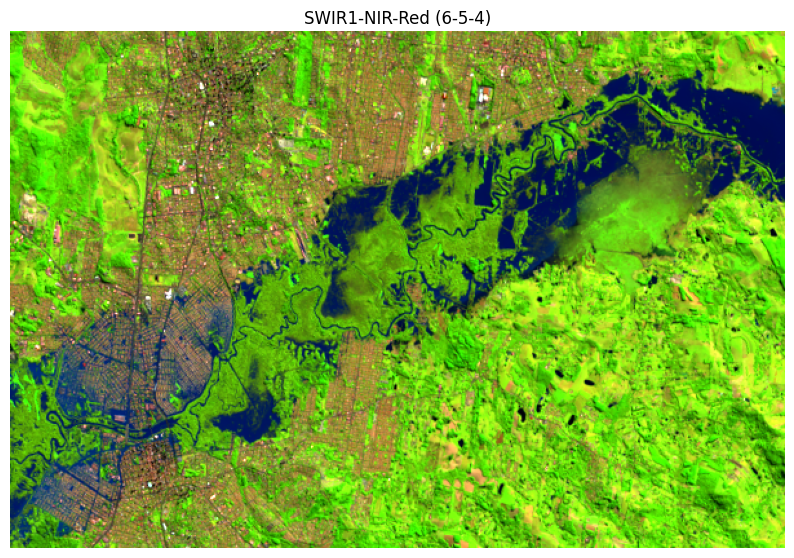

In [ ]:
# ============================================================
# IMAGE PLOT
# ============================================================

rgb = np.dstack([
    image["swir1"],  # R
    image["nir"],    # G
    image["red"]     # B
])

p2, p98 = np.percentile(rgb, (2, 98))

rgb = (rgb - p2) / (p98 - p2)
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.axis("off")
plt.title("SWIR1-NIR-Red (6-5-4)")
plt.show()

In [ ]:
# ============================================================
# AUXILIARY FUNCTIONS
# ============================================================

def safe_divide(numerator, denominator):
    """Equivalent to raster algebra division, avoiding invalid divisions."""
    with np.errstate(divide="ignore", invalid="ignore"):
        result = np.divide(numerator, denominator)
        result[~np.isfinite(result)] = np.nan
    return result.astype("float32")


def classify_threshold(index_array, threshold_value, water_above=True):
    """
    Reclassify raster using threshold logic equivalent to terra::classify.

    water_above=True:
        (-Inf, threshold] = 0; (threshold, Inf) = 1
    water_above=False:
        (-Inf, threshold] = 1; (threshold, Inf) = 0
    """
    if water_above:
        classified = np.where(index_array > threshold_value, 1, 0)
    else:
        classified = np.where(index_array <= threshold_value, 1, 0)

    classified = classified.astype("uint8")
    classified[~valid_mask | np.isnan(index_array)] = 0
    return classified


def classify_positive(index_array):
    """Equivalent to class_matrix <- c(-Inf, 0, 0, 0, Inf, 1)."""
    classified = np.where(index_array > 0, 1, 0).astype("uint8")
    classified[~valid_mask | np.isnan(index_array)] = 0
    return classified


def write_raster(array, output_path, dtype=None):
    """Export raster preserving the input image georeferencing."""
    output_path = Path(output_path)
    out_profile = profile.copy()
    out_profile.update(count=1, compress="lzw")

    if dtype is None:
        dtype = str(array.dtype)
    out_profile.update(dtype=dtype)

    if np.issubdtype(np.dtype(dtype), np.integer):
        out_profile.update(nodata=0)
        array_to_write = np.nan_to_num(array, nan=0).astype(dtype)
    else:
        out_profile.update(nodata=np.nan)
        array_to_write = array.astype(dtype)

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(array_to_write, 1)


def plot_raster(array, title, categorical=False):
    """Plot raster similarly to plot() in R. Comment calls if batch execution is preferred."""
    plt.figure(figsize=(8, 6))
    if categorical:
        plt.imshow(array, cmap="Blues", interpolation="nearest")
    else:
        plt.imshow(array, interpolation="nearest")
        plt.colorbar(label="Value")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def correct_with_sum567(water_map, sum567_threshold):
    """Noise filtering based on NIR + SWIR1 + SWIR2."""
    sum567_index = image["nir"] + image["swir1"] + image["swir2"]
    sum567_map = classify_threshold(sum567_index, sum567_threshold, water_above=True)
    water_map_filtered = water_map.astype("int16") - sum567_map.astype("int16")
    return classify_positive(water_map_filtered.astype("float32"))


def correct_with_red(water_map, red_threshold):
    """Noise filtering based on red band, following the inverted R classification."""
    red_map = classify_threshold(image["red"], red_threshold, water_above=False)
    water_map_filtered = water_map.astype("int16") - red_map.astype("int16")
    return classify_positive(water_map_filtered.astype("float32"))


def calculate_water_area_km2(water_map):
    """Calculate water area in km² from binary water map."""
    pixel_width = abs(profile["transform"].a)
    pixel_height = abs(profile["transform"].e)
    pixel_area_km2 = (pixel_width * pixel_height) / 1e6
    return float(np.nansum(water_map == 1) * pixel_area_km2)




In [ ]:
# ============================================================
# STEP 3 - THRESHOLDS
# ============================================================

# Adaptative Thresholds (Below, use the reference values or adjust the values to match local thresholds)

threshold = {
    "ndwi1": 0.012,
    "ndwi2": 0.055,
    "ndwi3": 0.231,
    "mndwi": 0.109,
    "wri": 0.979,
    "ndfi1": 0.094,
    "ndfi2": 0.276,
    "aweish": -0.132,
    "aweinsh": -0.092,
    "wi2015": 1.515,
    "mbwi": -0.124,
    "wi2020": 0.037,
}

# Filter Noise (Below, modify the values or enter 1000 for sum567 and -1000 for red_, in these cases, noise will not be removed)

filter_noise = {
    "sum567_ndwi1": 0.373,
    "sum567_ndwi2": 0.373,
    "sum567_ndwi3": 0.353,
    "sum567_mndwi": 0.369,
    "sum567_wri": 0.373,
    "sum567_ndfi1": 0.369,
    "sum567_ndfi2": 0.369,
    "red_aweish": 0.039,
    "red_aweinsh": 0.039,
    "sum567_wi2015": 0.373,
    "red_mbwi": 0.039,
    "sum567_wi2020": 0.353,
}

/tmp/ipykernel_1236/139252803.py:99: RuntimeWarning: overflow encountered in divide
  wi2020_index = (image["blue"] - image["swir2"]) / ((image["nir"] + image["swir1"] + image["swir2"] / 3))


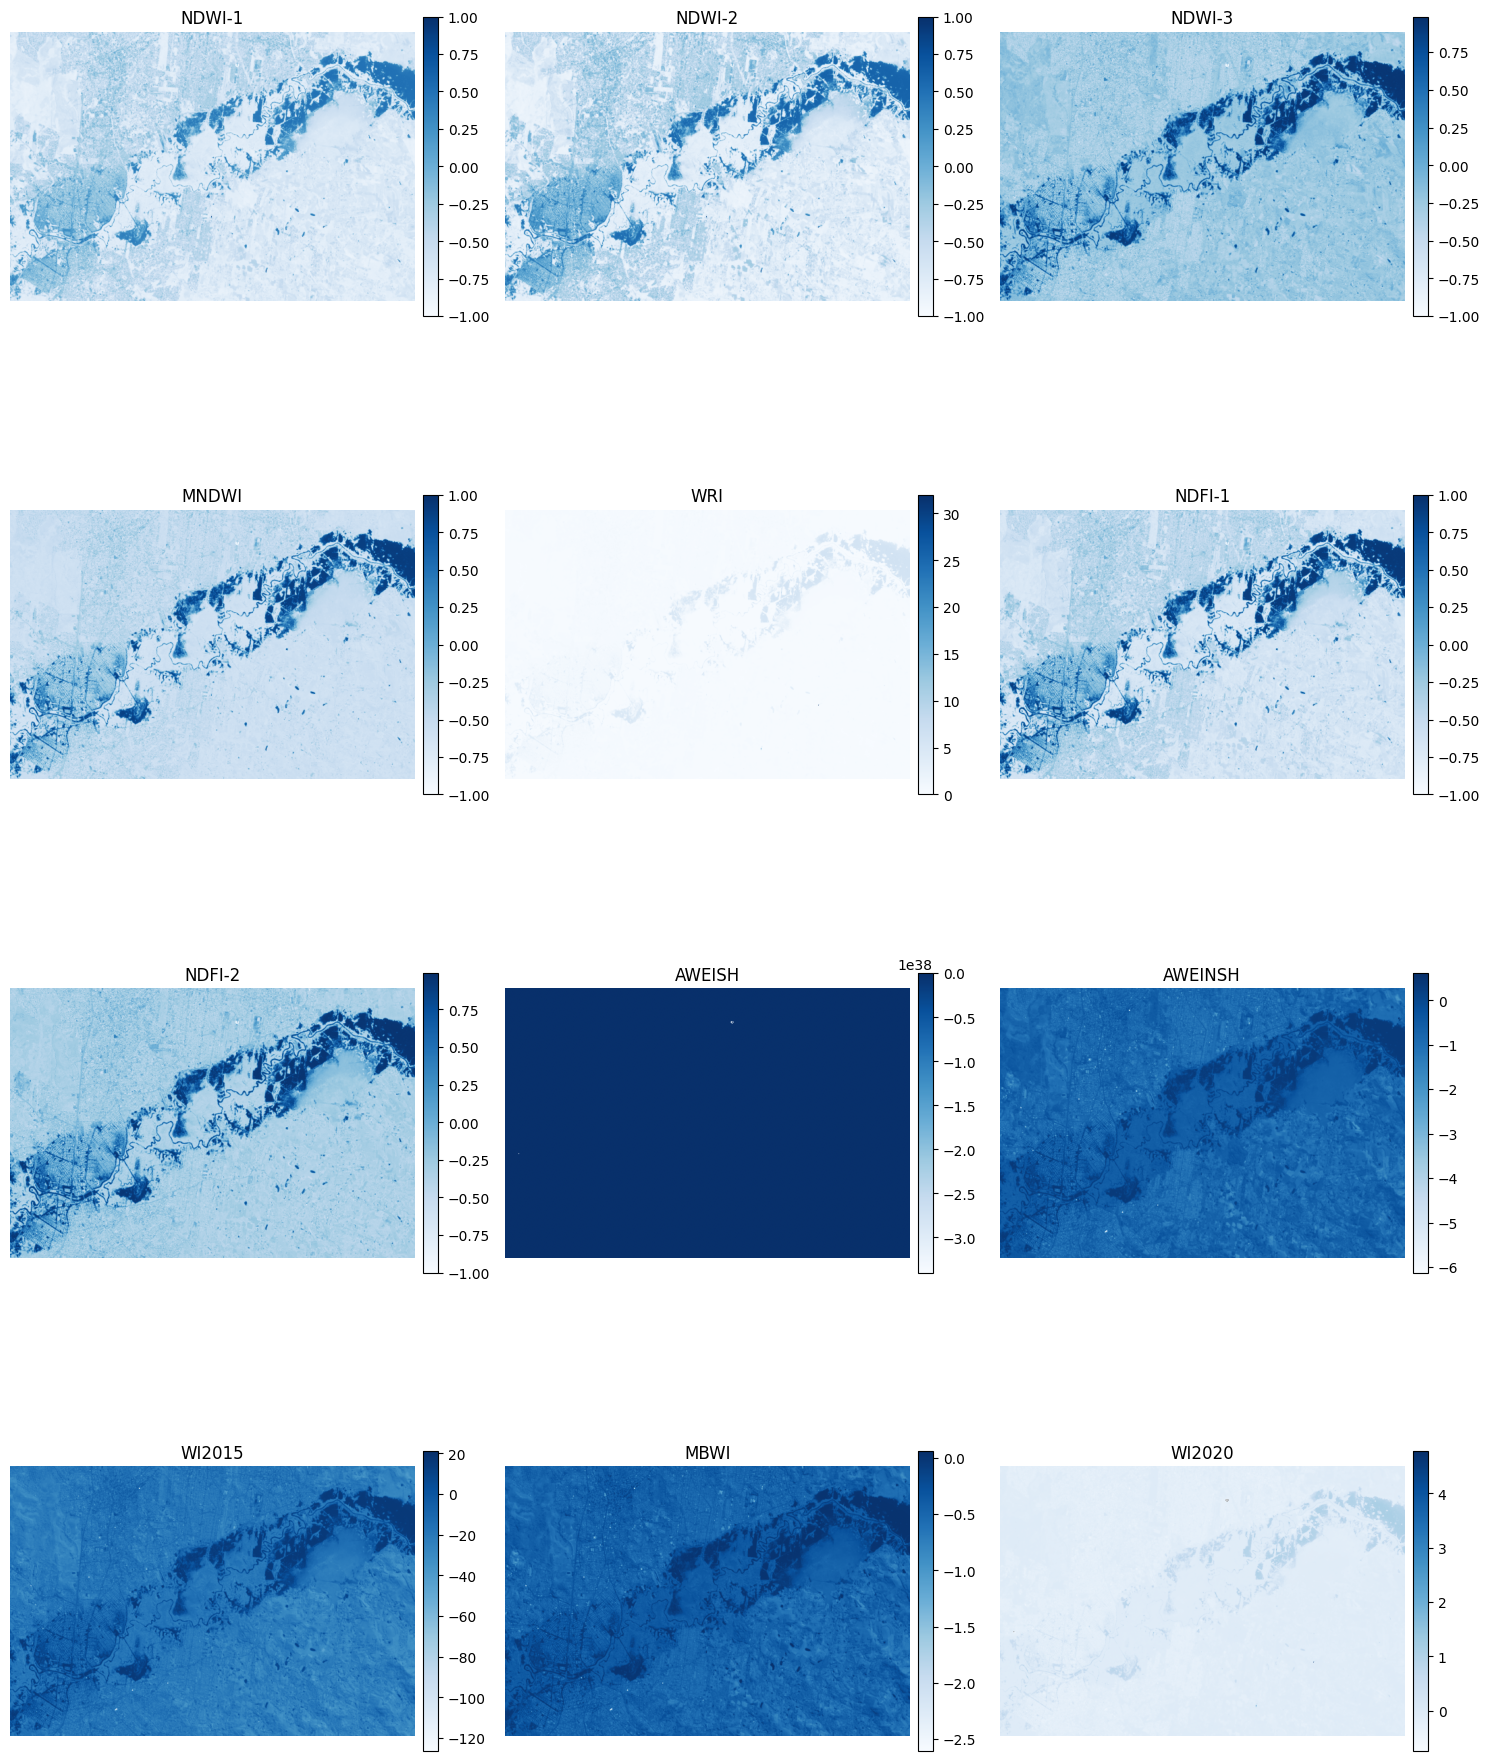

In [ ]:
# ============================================================
# STEP 4 - CALCULATE SPECTRAL WATER INDEX
# ============================================================

spectral_index = {}

# ============================================================
# NDWI-1 (Normalized Difference Water Index) - McFeeters (1996)
# ============================================================

ndwi1_index = safe_divide(image["green"] - image["nir"], image["green"] + image["nir"])
spectral_index["NDWI-1"] = ndwi1_index
write_raster(ndwi1_index, index_dir / "ndwi1_index.tif", dtype="float32")

# ============================================================================
# NDWI-2 (Modified Normalized Difference Water Index) - Rogers & Kearney (2004)
# ============================================================================

ndwi2_index = safe_divide(image["red"] - image["nir"], image["red"] + image["nir"])
spectral_index["NDWI-2"] = ndwi2_index
write_raster(ndwi2_index, index_dir / "ndwi2_index.tif", dtype="float32")

# ============================================================================
# NDWI-3 (Modified Normalized Difference Water Index) - Ouma & Tateishi (2006)
# ============================================================================

ndwi3_index = safe_divide(image["green"] - image["swir2"], image["green"] + image["swir2"])
spectral_index["NDWI-3"] = ndwi3_index
write_raster(ndwi3_index, index_dir / "ndwi3_index.tif", dtype="float32")

# ================================================================
# MNDWI (Modified Normalized Difference Water Index) - Xu (2006)
# ================================================================

mndwi_index = safe_divide(image["green"] - image["swir1"], image["green"] + image["swir1"])
spectral_index["MNDWI"] = mndwi_index
write_raster(mndwi_index, index_dir / "mndwi_index.tif", dtype="float32")

# ===================================
# WRI (Water Ratio Index) - Li (2010)
# ===================================

wri_index = safe_divide(image["green"] + image["red"], image["nir"] + image["swir1"])
spectral_index["WRI"] = wri_index
write_raster(wri_index, index_dir / "wri_index.tif", dtype="float32")

# ====================================================================
# NDFI-1 (Normalized Difference Flood Index) - Boschetti et al. (2014)
# ====================================================================

ndfi1_index = safe_divide(image["red"] - image["swir1"], image["red"] + image["swir1"])
spectral_index["NDFI-1"] = ndfi1_index
write_raster(ndfi1_index, index_dir / "ndfi1_index.tif", dtype="float32")

# ====================================================================
# NDFI-2 (Normalized Difference Flood Index) - Boschetti et al. (2014)
# ====================================================================

ndfi2_index = safe_divide(image["red"] - image["swir2"], image["red"] + image["swir2"])
spectral_index["NDFI-2"] = ndfi2_index
write_raster(ndfi2_index, index_dir / "ndfi2_index.tif", dtype="float32")

# ================================================================
# AWEIsh (Automated Water Extraction Index) - Feyisa et al. (2014)
# ================================================================

aweish_index = image["blue"] + 0.25 * image["green"] - 1.5 * (image["nir"] + image["swir1"]) - 0.25 * image["swir2"]
spectral_index["AWEISH"] = aweish_index
write_raster(aweish_index, index_dir / "aweish_index.tif", dtype="float32")

# =================================================================
# AWEInsh (Automated Water Extraction Index) - Feyisa et al. (2014)
# =================================================================

aweinsh_index = 4 * (image["green"] - image["swir1"]) - (0.25 * image["nir"] + 2.75 * image["swir2"])
spectral_index["AWEINSH"] = aweinsh_index
write_raster(aweinsh_index, index_dir / "aweinsh_index.tif", dtype="float32")

# ================================================
# WI2015 (Water Index 2015) - Fisher et al. (2016)
# ================================================

wi2015_index = 1.7204 + 171 * image["green"] + 3 * image["red"] - 70 * image["nir"] - 45 * image["swir1"] - 71 * image["swir2"]
spectral_index["WI2015"] = wi2015_index
write_raster(wi2015_index, index_dir / "wi2015_index.tif", dtype="float32")

# ==================================================
# MBWI (Multi-Band Water Index) - Wang et al. (2018)
# ==================================================

mbwi_index = 2 * image["green"] - image["red"] - image["nir"] - image["swir1"] - image["swir2"]
spectral_index["MBWI"] = mbwi_index
write_raster(mbwi_index, index_dir / "mbwi_index.tif", dtype="float32")

# ================================================
# WI2020 (Water Index 2020) - Mishra & Pant (2021)
# ================================================

wi2020_index = (image["blue"] - image["swir2"]) / ((image["nir"] + image["swir1"] + image["swir2"] / 3))
spectral_index["WI2020"] = wi2020_index
write_raster(wi2020_index, index_dir / "wi2020_index.tif", dtype="float32")

# ============================================================
# INDEX PLOTS
# ============================================================

#import matplotlib.pyplot as plt
#import numpy as np

# Mapas corrigidos gerados no Step 4
maps_to_plot = spectral_index

n_maps = len(maps_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_maps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, (name, raster) in zip(axes, maps_to_plot.items()):
    im = ax.imshow(raster, cmap="Blues")
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)

# Remove painéis vazios
for ax in axes[len(maps_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

index_maps = {
    "NDWI-1": ndwi1_index,
    "NDWI-2": ndwi2_index,
    "NDWI-3": ndwi3_index,
    "MNDWI": mndwi_index,
    "WRI": wri_index,
    "NDFI-1": ndfi1_index,
    "NDFI-2": ndfi2_index,
    "AWEIsh": aweish_index,
    "AWEInsh": aweinsh_index,
    "WI2015": wi2015_index,
    "MBWI": mbwi_index,
    "WI2020": wi2020_index,
}

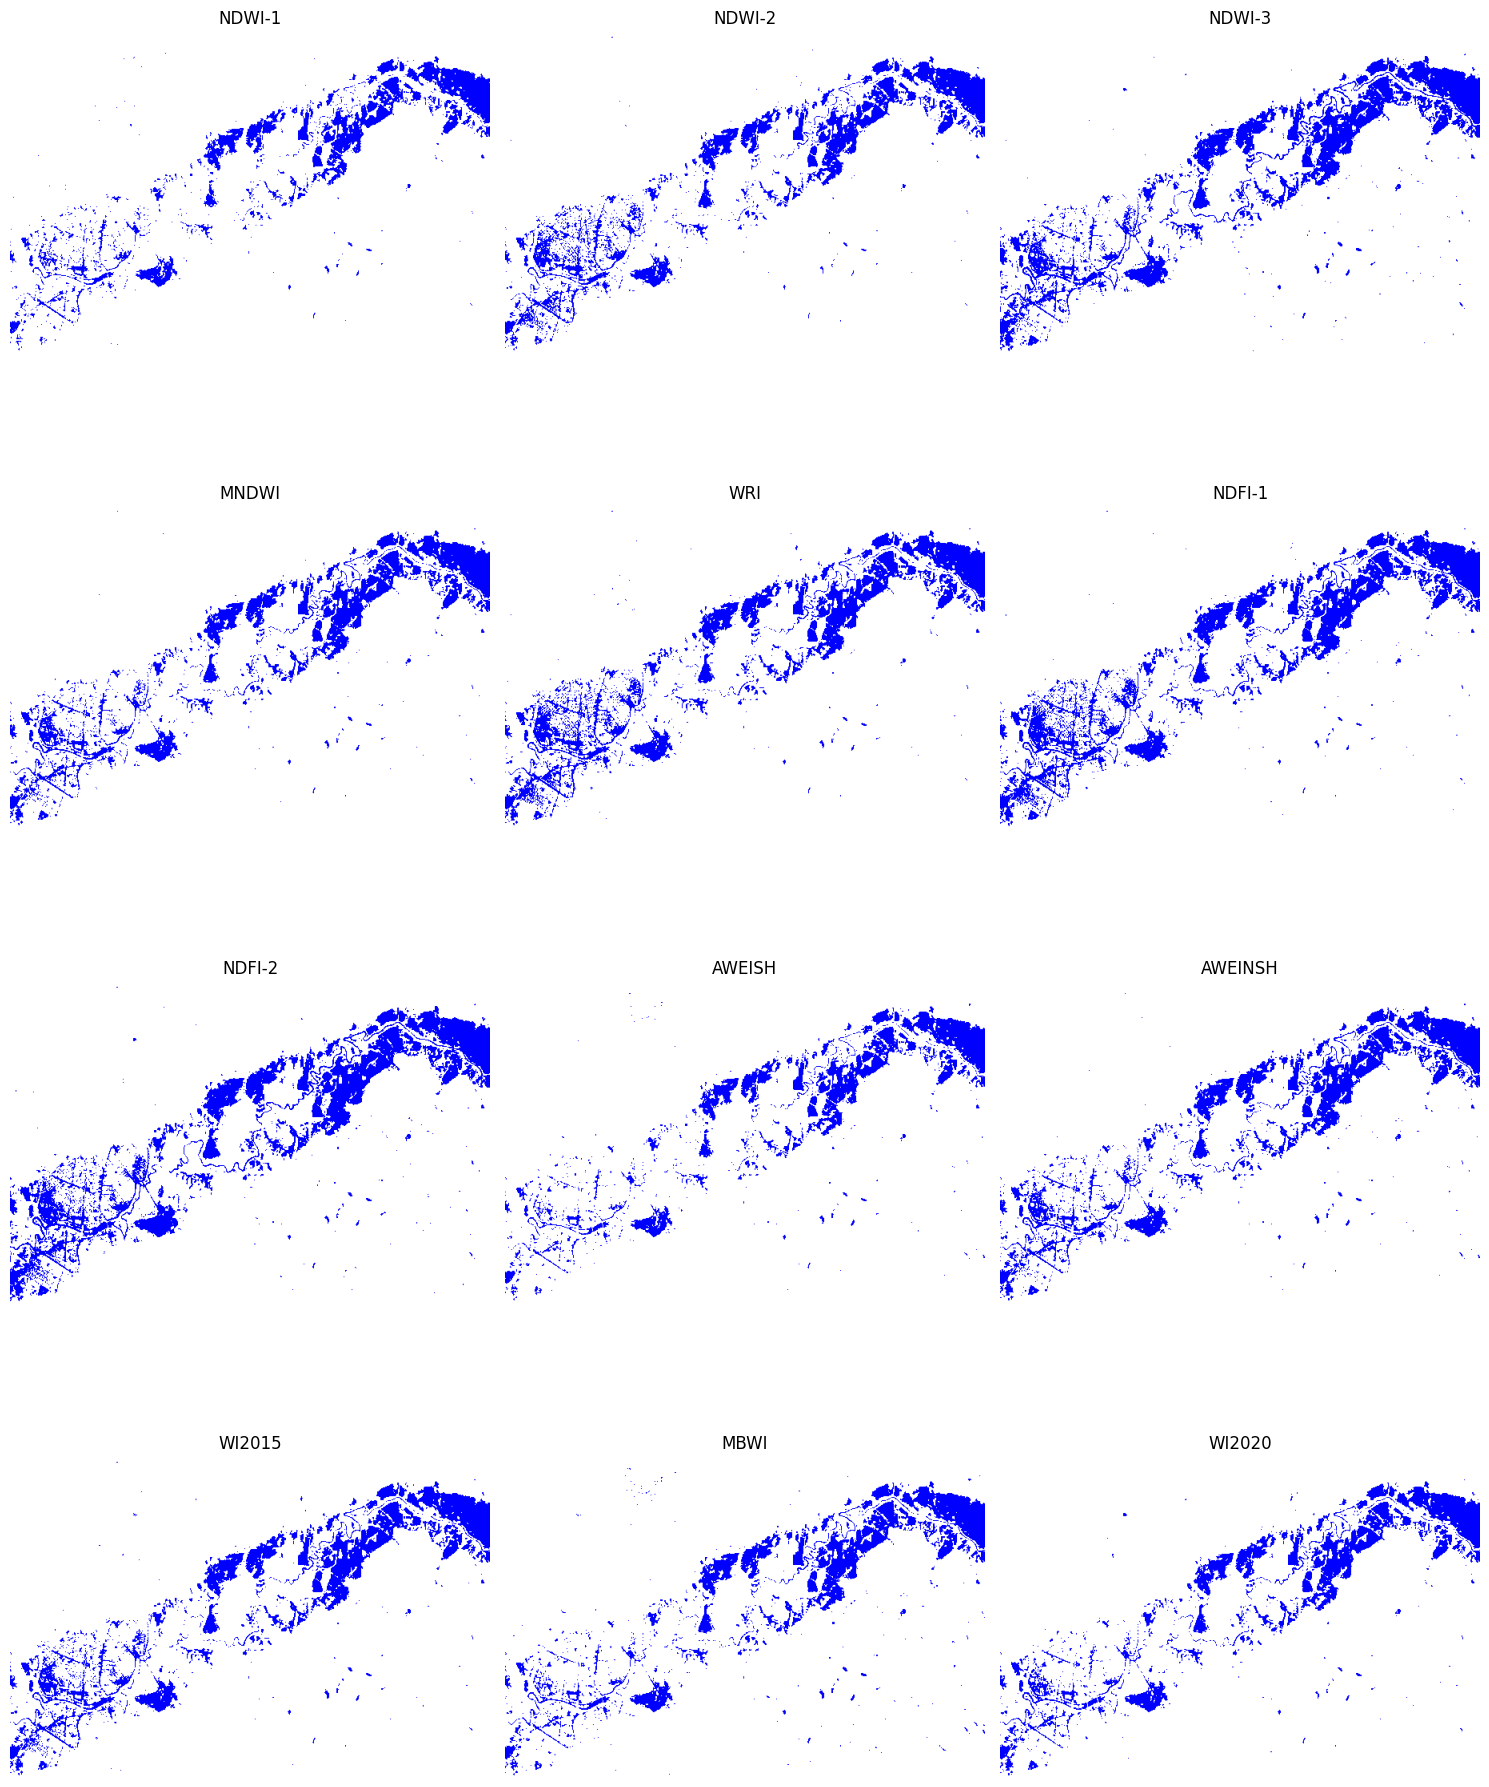

In [ ]:
# ============================================================
# STEP 5 - THRESHOLD SPECTRAL WATER INDEX
# ============================================================

water_maps = {}

# ============================================================
# NDWI-1 (Normalized Difference Water Index) - McFeeters (1996)
# ============================================================

ndwi1_water_map = classify_threshold(ndwi1_index, threshold["ndwi1"])
water_maps["NDWI-1"] = ndwi1_water_map
write_raster(ndwi1_water_map, map_dir / "ndwi1_water_map.tif", dtype="uint8")

# ============================================================================
# NDWI-2 (Modified Normalized Difference Water Index) - Rogers & Kearney (2004)
# ============================================================================

ndwi2_water_map = classify_threshold(ndwi2_index, threshold["ndwi2"])
water_maps["NDWI-2"] = ndwi2_water_map
write_raster(ndwi2_water_map, map_dir / "ndwi2_water_map.tif", dtype="uint8")

# ============================================================================
# NDWI-3 (Modified Normalized Difference Water Index) - Ouma & Tateishi (2006)
# ============================================================================

ndwi3_water_map = classify_threshold(ndwi3_index, threshold["ndwi3"])
water_maps["NDWI-3"] = ndwi3_water_map
write_raster(ndwi3_water_map, map_dir / "ndwi3_water_map.tif", dtype="uint8")

# ================================================================
# MNDWI (Modified Normalized Difference Water Index) - Xu (2006)
# ================================================================

mndwi_water_map = classify_threshold(mndwi_index, threshold["mndwi"])
water_maps["MNDWI"] = mndwi_water_map
write_raster(mndwi_water_map, map_dir / "mndwi_water_map.tif", dtype="uint8")

# ===================================
# WRI (Water Ratio Index) - Li (2010)
# ===================================

wri_water_map = classify_threshold(wri_index, threshold["wri"])
water_maps["WRI"] = wri_water_map
write_raster(wri_water_map, map_dir / "wri_water_map.tif", dtype="uint8")

# ====================================================================
# NDFI-1 (Normalized Difference Flood Index) - Boschetti et al. (2014)
# ====================================================================

ndfi1_water_map = classify_threshold(ndfi1_index, threshold["ndfi1"])
water_maps["NDFI-1"] = ndfi1_water_map
write_raster(ndfi1_water_map, map_dir / "ndfi1_water_map.tif", dtype="uint8")

# ====================================================================
# NDFI-2 (Normalized Difference Flood Index) - Boschetti et al. (2014)
# ====================================================================

ndfi2_water_map = classify_threshold(ndfi2_index, threshold["ndfi2"])
water_maps["NDFI-2"] = ndfi2_water_map
write_raster(ndfi2_water_map, map_dir / "ndfi2_water_map.tif", dtype="uint8")

# ================================================================
# AWEIsh (Automated Water Extraction Index) - Feyisa et al. (2014)
# ================================================================

aweish_water_map = classify_threshold(aweish_index, threshold["aweish"])
water_maps["AWEISH"] = aweish_water_map
write_raster(aweish_water_map, map_dir / "aweish_water_map.tif", dtype="uint8")

# =================================================================
# AWEInsh (Automated Water Extraction Index) - Feyisa et al. (2014)
# =================================================================

aweinsh_water_map = classify_threshold(aweinsh_index, threshold["aweinsh"])
water_maps["AWEINSH"] = aweinsh_water_map
write_raster(aweinsh_water_map,map_dir / "aweinsh_water_map.tif", dtype="uint8")

# ================================================
# WI2015 (Water Index 2015) - Fisher et al. (2016)
# ================================================

wi2015_water_map = classify_threshold(wi2015_index, threshold["wi2015"])
water_maps["WI2015"] = wi2015_water_map
write_raster(wi2015_water_map, map_dir / "wi2015_water_map.tif", dtype="uint8")

# ==================================================
# MBWI (Multi-Band Water Index) - Wang et al. (2018)
# ==================================================

mbwi_water_map = classify_threshold(mbwi_index, threshold["mbwi"])
water_maps["MBWI"] = mbwi_water_map
write_raster(mbwi_water_map, map_dir / "mbwi_water_map.tif", dtype="uint8")

# ================================================
# WI2020 (Water Index 2020) - Mishra & Pant (2021)
# ================================================

wi2020_water_map = classify_threshold(wi2020_index, threshold["wi2020"])
water_maps["WI2020"] = wi2020_water_map
write_raster(wi2020_water_map, map_dir / "wi2020_water_map.tif", dtype="uint8")

# ============================================================
# WATER MAP PLOTS
# ============================================================

# Mapas corrigidos gerados no Step 4
maps_to_plot = water_maps

n_maps = len(maps_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_maps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, (name, raster) in zip(axes, maps_to_plot.items()):
    ax.imshow(raster, cmap=binary_cmap, vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis("off")

# Remove painéis vazios
for ax in axes[len(maps_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

index_maps = {
    "NDWI-1": ndwi1_water_map,
    "NDWI-2": ndwi2_water_map,
    "NDWI-3": ndwi3_water_map,
    "MNDWI": mndwi_water_map,
    "WRI": wri_water_map,
    "NDFI-1": ndfi1_water_map,
    "NDFI-2": ndfi2_water_map,
    "AWEIsh": aweish_water_map,
    "AWEInsh": aweinsh_water_map,
    "WI2015": wi2015_water_map,
    "MBWI": mbwi_water_map,
    "WI2020": wi2020_water_map,
}


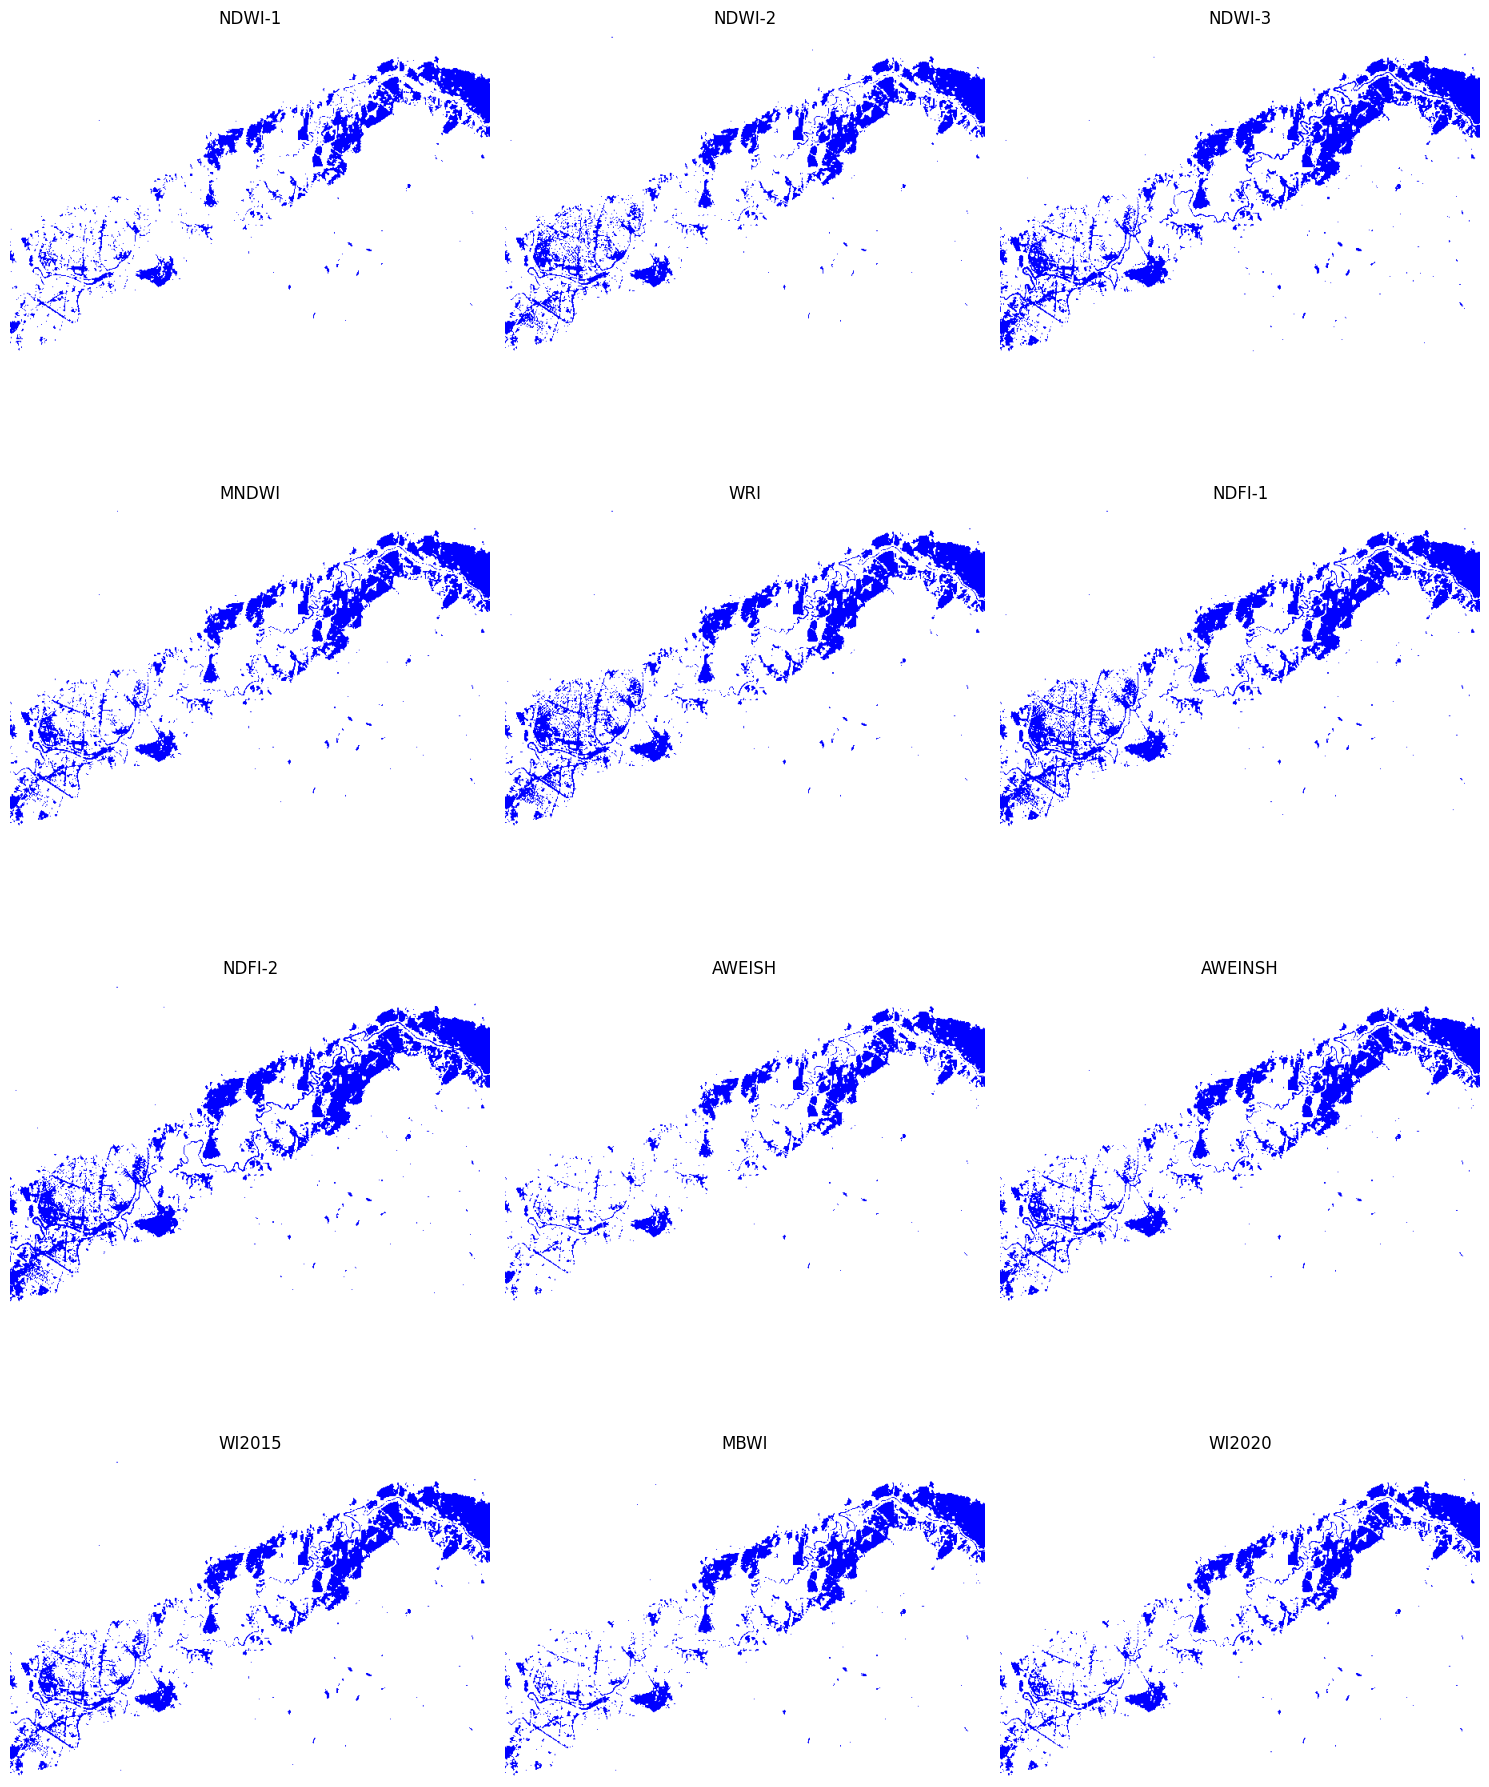

In [ ]:
# ============================================================
# STEP 6 - CORRECTED WATER MAPS
# ============================================================

corrected_water_maps = {}
area_records = []

# ============================================================
# NDWI-1 (Normalized Difference Water Index) - McFeeters (1996)
# ============================================================

ndwi1_water_map_corrected = correct_with_sum567(ndwi1_water_map, filter_noise["sum567_ndwi1"])
corrected_water_maps["NDWI-1"] = ndwi1_water_map_corrected
write_raster(ndwi1_water_map_corrected, corrected_map_dir / "ndwi1_water_map_corrected.tif", dtype="uint8")

# ============================================================================
# NDWI-2 (Modified Normalized Difference Water Index) - Rogers & Kearney (2004)
# ============================================================================

ndwi2_water_map_corrected = correct_with_sum567(ndwi2_water_map, filter_noise["sum567_ndwi2"])
corrected_water_maps["NDWI-2"] = ndwi2_water_map_corrected
write_raster(ndwi2_water_map_corrected, corrected_map_dir / "ndwi2_water_map_corrected.tif", dtype="uint8")

# ============================================================================
# NDWI-3 (Modified Normalized Difference Water Index) - Ouma & Tateishi (2006)
# ============================================================================

ndwi3_water_map_corrected = correct_with_sum567(ndwi3_water_map, filter_noise["sum567_ndwi3"])
corrected_water_maps["NDWI-3"] = ndwi3_water_map_corrected
write_raster(ndwi3_water_map_corrected, corrected_map_dir / "ndwi3_water_map_corrected.tif", dtype="uint8")

# ================================================================
# MNDWI (Modified Normalized Difference Water Index) - Xu (2006)
# ================================================================

mndwi_water_map_corrected = correct_with_sum567(mndwi_water_map, filter_noise["sum567_mndwi"])
corrected_water_maps["MNDWI"] = mndwi_water_map_corrected
write_raster(mndwi_water_map_corrected, corrected_map_dir / "mndwi_water_map_corrected.tif", dtype="uint8")

# ===================================
# WRI (Water Ratio Index) - Li (2010)
# ===================================

wri_water_map_corrected = correct_with_sum567(wri_water_map, filter_noise["sum567_wri"])
corrected_water_maps["WRI"] = wri_water_map_corrected
write_raster(wri_water_map_corrected, corrected_map_dir / "wri_water_map_corrected.tif", dtype="uint8")

# ====================================================================
# NDFI-1 (Normalized Difference Flood Index) - Boschetti et al. (2014)
# ====================================================================

ndfi1_water_map_corrected = correct_with_sum567(ndfi1_water_map, filter_noise["sum567_ndfi1"])
corrected_water_maps["NDFI-1"] = ndfi1_water_map_corrected
write_raster(ndfi1_water_map_corrected, corrected_map_dir / "ndfi1_water_map_corrected.tif", dtype="uint8")

# ====================================================================
# NDFI-2 (Normalized Difference Flood Index) - Boschetti et al. (2014)
# ====================================================================

ndfi2_water_map_corrected = correct_with_sum567(ndfi2_water_map, filter_noise["sum567_ndfi2"])
corrected_water_maps["NDFI-2"] = ndfi2_water_map_corrected
write_raster(ndfi2_water_map_corrected, corrected_map_dir / "ndfi2_water_map_corrected.tif", dtype="uint8")

# ================================================================
# AWEIsh (Automated Water Extraction Index) - Feyisa et al. (2014)
# ================================================================

aweish_water_map_corrected = correct_with_red(aweish_water_map, filter_noise["red_aweish"])
corrected_water_maps["AWEISH"] = aweish_water_map_corrected
write_raster(aweish_water_map_corrected, corrected_map_dir / "aweish_water_map_corrected.tif", dtype="uint8")

# =================================================================
# AWEInsh (Automated Water Extraction Index) - Feyisa et al. (2014)
# =================================================================

aweinsh_water_map_corrected = correct_with_red(aweinsh_water_map, filter_noise["red_aweinsh"])
corrected_water_maps["AWEINSH"] = aweinsh_water_map_corrected
write_raster(aweinsh_water_map_corrected, corrected_map_dir / "aweinsh_water_map_corrected.tif", dtype="uint8")

# ================================================
# WI2015 (Water Index 2015) - Fisher et al. (2016)
# ================================================

wi2015_water_map_corrected = correct_with_sum567(wi2015_water_map, filter_noise["sum567_wi2015"])
corrected_water_maps["WI2015"] = wi2015_water_map_corrected
write_raster(wi2015_water_map_corrected, corrected_map_dir / "wi2015_water_map_corrected.tif", dtype="uint8")

# ==================================================
# MBWI (Multi-Band Water Index) - Wang et al. (2018)
# ==================================================

mbwi_water_map_corrected = correct_with_red(mbwi_water_map, filter_noise["red_mbwi"])
corrected_water_maps["MBWI"] = mbwi_water_map_corrected
write_raster(mbwi_water_map_corrected, corrected_map_dir / "mbwi_water_map_corrected.tif", dtype="uint8")

# ================================================
# WI2020 (Water Index 2020) - Mishra & Pant (2021)
# ================================================

wi2020_water_map_corrected = correct_with_sum567(wi2020_water_map, filter_noise["sum567_wi2020"])
corrected_water_maps["WI2020"] = wi2020_water_map_corrected
write_raster(wi2020_water_map_corrected, corrected_map_dir / "wi2020_water_map_corrected.tif", dtype="uint8")

# ============================================================
# WATER MAP PLOTS
# ============================================================

# Mapas corrigidos gerados no Step 4
maps_to_plot = corrected_water_maps

n_maps = len(maps_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_maps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, (name, raster) in zip(axes, maps_to_plot.items()):
    ax.imshow(raster, cmap=binary_cmap, vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis("off")

# Remove painéis vazios
for ax in axes[len(maps_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

index_maps = {
    "NDWI-1": ndwi1_water_map_corrected,
    "NDWI-2": ndwi2_water_map_corrected,
    "NDWI-3": ndwi3_water_map_corrected,
    "MNDWI": mndwi_water_map_corrected,
    "WRI": wri_water_map_corrected,
    "NDFI-1": ndfi1_water_map_corrected,
    "NDFI-2": ndfi2_water_map_corrected,
    "AWEIsh": aweish_water_map_corrected,
    "AWEInsh": aweinsh_water_map_corrected,
    "WI2015": wi2015_water_map_corrected,
    "MBWI": mbwi_water_map_corrected,
    "WI2020": wi2020_water_map_corrected,
}

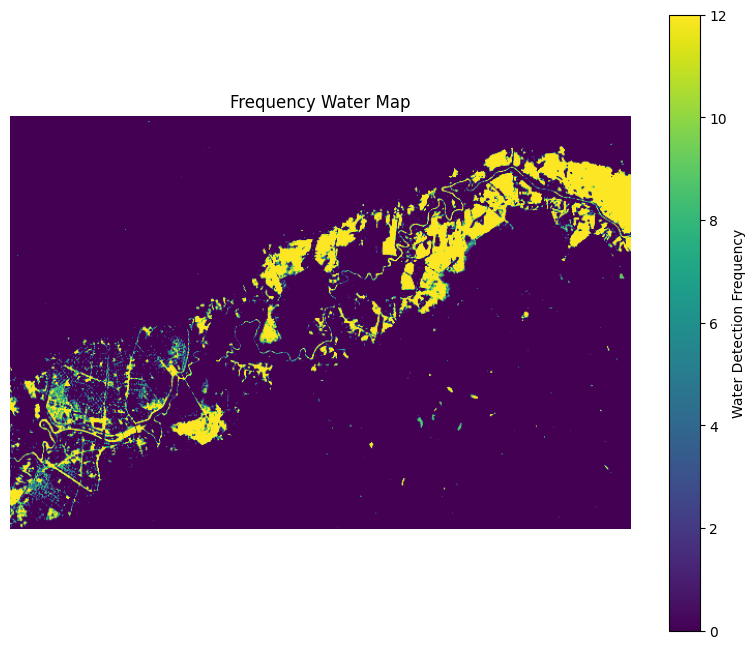

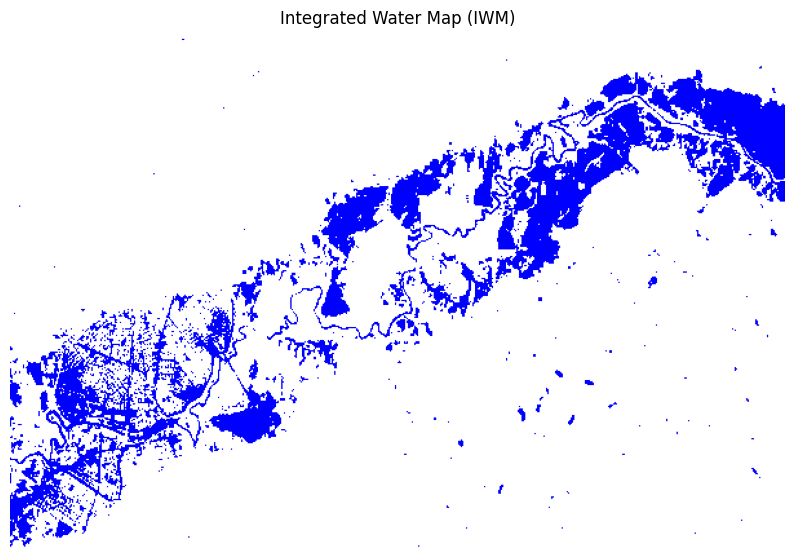

In [ ]:
# ============================================================
# STEP 7 - INTEGRATE WATER MAPS
# ============================================================

# Integrated Water Maps

water_frequency_map = (
    ndwi1_water_map_corrected + ndwi2_water_map_corrected +
    ndwi3_water_map_corrected + mndwi_water_map_corrected +
    wri_water_map_corrected + ndfi1_water_map_corrected +
    ndfi2_water_map_corrected + aweish_water_map_corrected +
    aweinsh_water_map_corrected + wi2015_water_map_corrected +
    mbwi_water_map_corrected + wi2020_water_map_corrected
).astype("uint8")

write_raster(water_frequency_map, iwm_map_dir / "integrated_water_frequency_map.tif", dtype="uint8")

integrated_water_map = classify_positive(water_frequency_map.astype("float32"))
write_raster(integrated_water_map, iwm_map_dir / "integrated_water_binary_map.tif", dtype="uint8")

# ============================================================
# IWM AND FREQUENCY MAP PLOTS
# ============================================================

# Frequency map

plt.figure(figsize=(10,8))
im = plt.imshow(water_frequency_map, cmap="viridis")
plt.colorbar(im, label="Water Detection Frequency")
plt.title("Frequency Water Map")
plt.axis("off")
plt.show()

#import matplotlib.pyplot as plt
#from matplotlib.colors import ListedColormap
#cmap = ListedColormap(["white", "blue"])

plt.figure(figsize=(10,8))
plt.imshow(integrated_water_map, cmap=binary_cmap)
plt.title("Integrated Water Map (IWM)")
plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# STEP 8 - CALCULATE WATER AREA FROM THRESHOLDED WATER INDICES
# ============================================================

for name, water_map in corrected_water_maps.items():
    area_records.append({"name": name, "area": calculate_water_area_km2(water_map)})

area_records.append({"name": "IWM", "area": calculate_water_area_km2(integrated_water_map)})

area_df = pd.DataFrame(area_records).sort_values("area", ascending=False).reset_index(drop=True)
print(area_df)

area_df.to_csv(output_dir / "water_area_km2.csv", index=False)


       name     area
0       IWM  26.5599
1    NDFI-2  25.2117
2    NDFI-1  23.2479
3    NDWI-3  23.1993
4       WRI  21.0393
5   AWEINSH  20.0286
6    WI2015  20.0178
7     MNDWI  19.2114
8    NDWI-2  18.2664
9    WI2020  17.2971
10     MBWI  17.0577
11   AWEISH  14.7375
12   NDWI-1  14.4720


## Optional plots and output download

In [ ]:
# Uncomment the lines below to display outputs during interactive execution.
# plot_raster(water_frequency_map, "Water Frequency Map")
# plot_raster(integrated_water_map, "Integrated Water Map", categorical=True)

# Compactar saídas para download no Colab
!zip -qr /content/floodisi_outputs.zip /content/floodisi_outputs
print("Outputs compactados em: /content/floodisi_outputs.zip")

Outputs compactados em: /content/floodisi_outputs.zip


In [ ]:
# ============================================================
# REFERENCES
# ============================================================

# BAZZAN, T.; RENNÓ, C.D.; RECZIEGEL, E.W.; GUASSELLI, L.A.; KORB, C.C.
#Flood Detection Integrating Spectral Indices (FLOODISI):
# A Novel Approach to Open-Water Mapping. Geosciences 2026, 16, 325. https://doi.org/10.3390/geosciences16080325

# BOSCHETTI, M.; NUTINI, F.; MANFRON, G.; BRIVIO, P.A.; NELSON, A.
# Comparative Analysis of Normalised Difference Spectral Indices Derived from
# MODIS for Detecting Surface Water in Flooded Rice Cropping Systems. PLoS ONE, 9, 2014.

# FEYISA, G.L.; MEILBY, H.; FENSHOLT, R.; PROUD, S.R. Automated Water Extraction Index:
# a new technique for surface water mapping using Landsat imagery. Remote Sensing of Environment, v. 140, 23-35, 2014.

# FISHER, A.; FLOOD, N.; DANAHER, T. Comparing Landsat water index methods for
# automated water classification in eastern Australia. Remote Sensing of Environment, v. 175, 167-182, 2016.

# McFEETERS, S.K. The use of the Normalized Difference Water Index (NDWI) in the
# delineation of open water features. International Journal of Remote Sensing, v. 17, 1425-1432, 1996.

# MISHRA, V.K., PANT, T. Change analysis of water area and flood mapping using a novel water index 2020 (WI2020)
#for Landsat imagery, Geocarto International, 2021.

# OUMA, Y.O.; TATEISHI, R. A Water Index for Rapid Mapping of Shoreline Changes
# of Five East African Rift Valley Lakes: An Empirical Analysis Using Landsat TM
# and ETM+ Data. Int. J. Remote Sens. 27, 3153-3181, 2006.

# ROGERS, A.S.; KEARNEY, M.S. Reducing Signature Variability in Unmixing Coastal
# Marsh Thematic Mapper Scenes Using Spectral Indices. Int. J. Remote Sens., 25, 2317-2335, 2004.

# WANG, X.; XIE, S.; ZHANG, X.; CHEN, C.; GUO, H.; DU, J.; DUAN, Z.
# A robust Multi-Band Water Index (MBWI) for automated extraction of surface water
# from Landsat 8 OLI imagery. International Journal of Applied Earth Observation and Geoinformation, v. 68, 73-91, 2018.